# **MÓDULO 13**
# Projeto - Fundamentos da Descoberta de Dados

Nesse projeto trabalharemos com a base de dados de produtos de um supermercado do Chile.
A ideia é que vocês apliquem os conceitos estatísticos vistos no último módulo, mais os conceitos de visualizações de dados através de gráficos e finalizem publicando no seu github!

In [19]:
import pandas as pd
import matplotlib.pyplot as plt
import plotly.express as px
import seaborn as sns

In [10]:
from google.colab import files
uploaded = files.upload()
for filename in uploaded.keys():
  df = pd.read_csv(filename, delimiter=';')
  print(f'Arquivo carregado: {filename}')

  df.head(10)

Saving mercado.csv to mercado.csv
Arquivo carregado: mercado.csv


Faça a leitura dos dados do arquivo CSV:


Altere o código abaixo de acordo com seu diretório.

In [13]:
df = pd.read_csv(r"mercado.csv")

df.head(10)

,title,Marca,Preco_Normal,Preco_Desconto,Preco_Anterior,Desconto,Categoria
0,"Pack 12 un, Leche extra proteína 1 L",Loncoleche,19788,0,0,0,lacteos
1,"Pack 12 un, Leche chocolate receta original 1 L",Soprole,18228,0,0,0,lacteos
2,"Pack 12 un, Leche semidescremada chocolate 1 L",Soprole,18228,0,0,0,lacteos
3,"Pack 12 un, Leche semidescremada frutilla 1 L",Soprole,18228,0,0,0,lacteos
4,"Pack 12 un, Leche sin lactosa chocolate 1 L",Loncoleche,17988,0,0,0,lacteos
5,"Pack 12 un, Leche sin lactosa frutilla 1 L",Loncoleche,17988,0,0,0,lacteos
6,"Pack 12 un, Leche saborizada light chocolate 1 L",Loncoleche,17988,0,0,0,lacteos
7,"Pack 12 un, Leche saborizada frutilla 1 L",Colun,17388,0,0,0,lacteos
8,"Pack 12 un, Leche saborizada vainilla 1 L",Colun,17388,0,0,0,lacteos
9,"Pack 12 un, Leche saborizada manjar 1 L",Colun,17388,0,0,0,lacteos


Os campos do nosso dataframe são:

**Title:** Nome do produto.


**Marca:** A marca do produto.


**Preco_Normal:** O preço em que o produto costuma ser vendido quando não há desconto.


**Preco_Desconto:** O preço vendido após o desconto ser aplicado.


**Preco_Anterior:** Preço em que era comercializado o produto antes do desconto aplicado.


**Desconto:** Total de desconto aplicado.






As colunas que aparecem com valores 0 são para os produtos onde não tivemos descontos aplicados.


As categorias estão em espanhol!

# 1 - Traga a média e a mediana dos preços - coluna Preco_Normal - por categoria de produto.
# Identifique as categorias que parecem ter um valor de média abaixo ou acima da mediana.

In [14]:
#Seu código aqui para a média

media = df.groupby('Categoria')['Preco_Normal'].mean().sort_values(ascending=False)
print(media)



Categoria
comidas-preparadas            3095.043478
lacteos                       2385.219239
congelados                    2108.042553
belleza-y-cuidado-personal    1783.556485
frutas                        1724.473684
verduras                      1343.296875
instantaneos-y-sopas           765.491228
Name: Preco_Normal, dtype: float64


In [16]:
#Seu código aqui para a mediana

mediana = df.groupby('Categoria')['Preco_Normal'].median().sort_values(ascending=False)
print(mediana)

Categoria
comidas-preparadas            3290.0
belleza-y-cuidado-personal    1569.0
congelados                    1519.0
frutas                        1195.0
verduras                      1180.0
lacteos                        989.0
instantaneos-y-sopas           439.0
Name: Preco_Normal, dtype: float64


##categorias com outlier altos:
lacteos, congelados, belleza-y-cuidado-personal, frutas, verduras, instantaneos-y-sopas


##categorias com outlier baixos:

comidas preparadas


# 2 - Traga o desvio padrão por categoria de produto.
# Qual o comportamento da média e mediana nas categorias com maior desvio?


Nas categorias com maior desvio padrão, a média é maior que a mediana, indicando que alguns produtos muito caros elevam a média em relação à maioria dos itens.

In [17]:
#Seu código aqui

desvio = df.groupby('Categoria')['Preco_Normal'].std().sort_values(ascending=False)
print(desvio)


Categoria
lacteos                       3925.816164
belleza-y-cuidado-personal    2210.041719
congelados                    2111.539896
comidas-preparadas            2019.911428
frutas                        1639.151114
instantaneos-y-sopas          1170.232869
verduras                      1012.699625
Name: Preco_Normal, dtype: float64


Digite nesse campo o comportamento que você identificou.

As categorias com maior desvio padrão, como lacteos e belleza-y-cuidado-personal, apresentam grande variação de preços. Nelas, a média é maior que a mediana, indicando que alguns produtos muito caros elevam a média em relação à maioria dos itens. Já categorias com menor desvio padrão, como verduras e instantâneos, possuem preços mais homogêneos.


# 3 - Plot um boxplot da distribuição do Preco_Normal para a categoria que você identificou que tem o maior desvio padrão. Como é a distribuição desses dados segundo o boxplot? Você identifica muitos outliers?

Dica: Para trazer apenas os dados da categoria que você deseja você pode usar o df.loc[df['Categoria'] == 'CATEGORIA ESCOLHIDA'

                                             title       Marca  Preco_Normal  \
0             Pack 12 un, Leche extra proteína 1 L  Loncoleche         19788   
1  Pack 12 un, Leche chocolate receta original 1 L     Soprole         18228   
2   Pack 12 un, Leche semidescremada chocolate 1 L     Soprole         18228   
3    Pack 12 un, Leche semidescremada frutilla 1 L     Soprole         18228   
4      Pack 12 un, Leche sin lactosa chocolate 1 L  Loncoleche         17988   

   Preco_Desconto  Preco_Anterior  Desconto Categoria  
0               0               0         0   lacteos  
1               0               0         0   lacteos  
2               0               0         0   lacteos  
3               0               0         0   lacteos  
4               0               0         0   lacteos  


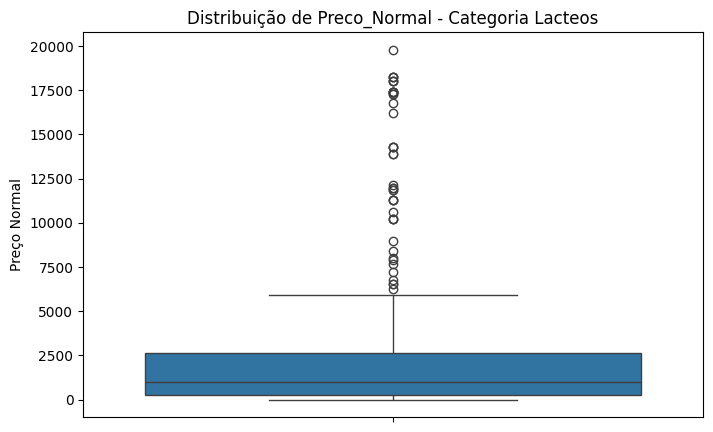

In [25]:
#Seu código aqui


df_lacteos = df.loc[df['Categoria'] == 'lacteos']


print(df_lacteos.head())


plt.figure(figsize=(8,5))
sns.boxplot(y=df_lacteos['Preco_Normal'], showfliers=True)
plt.title('Distribuição de Preco_Normal - Categoria Lacteos')
plt.ylabel('Preço Normal')
plt.show()


# 4 - Plote um gráfico de barras onde temos a média de descontos por categoria.

/tmp/ipykernel_1340/2827022876.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=media_descontos.index, y=media_descontos.values, palette="viridis")


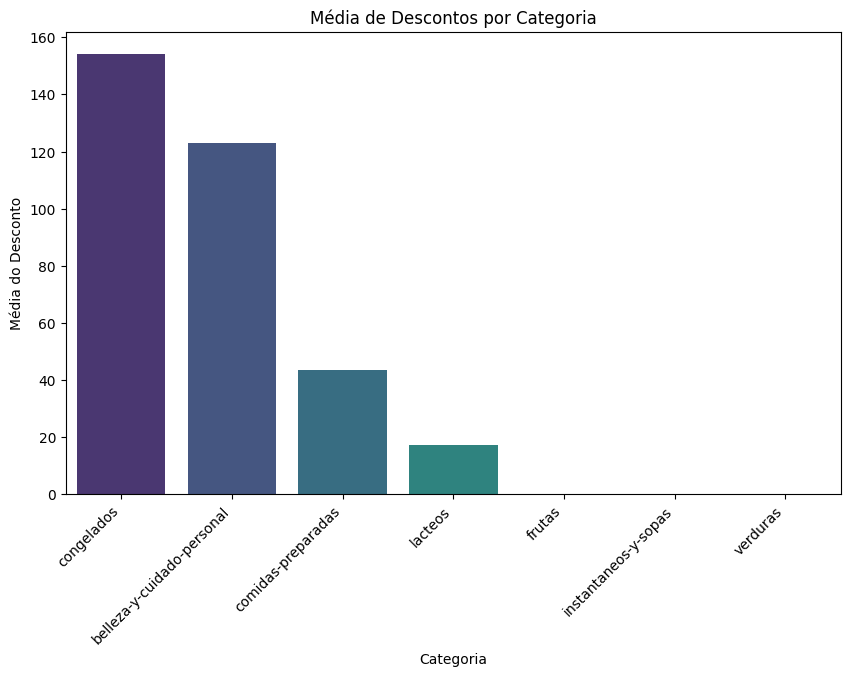

In [26]:
# Seu código aqui

media_descontos = df.groupby('Categoria')['Desconto'].mean().sort_values(ascending=False)


plt.figure(figsize=(10,6))
sns.barplot(x=media_descontos.index, y=media_descontos.values, palette="viridis")
plt.xticks(rotation=45, ha='right')
plt.ylabel('Média do Desconto')
plt.xlabel('Categoria')
plt.title('Média de Descontos por Categoria')
plt.show()


# 5 - Plote um gráfico de mapa interativo agrupando os dados por categoria, marca e trazendo a média de desconto.

In [27]:
# Seu código aqui

media_descontos = df.groupby(['Categoria', 'Marca'])['Desconto'].mean().reset_index()


fig = px.bar(
    media_descontos,
    x='Categoria',
    y='Desconto',
    color='Marca',
    barmode='group',
    hover_data=['Marca', 'Desconto'],
    title='Média de Descontos por Categoria e Marca'
)


fig.update_layout(
    xaxis_title='Categoria',
    yaxis_title='Média do Desconto',
    xaxis_tickangle=-45
)


fig.show()